In [5]:
from pprint import pprint

import numpy as np
from nd2reader import ND2Reader
from skimage import filters, measure, morphology, draw
import matplotlib.pyplot as plt

In [6]:
nd2_file_path = (
    r"C:\Users\skypa\projects_Python\particle_counting\data\1.5pc-.nd2"
)

with ND2Reader(nd2_file_path) as images:
    image_stack = np.array([frame for frame in images])
    metadata = images.metadata

pprint(metadata)

{'channels': ['532-647'],
 'date': datetime.datetime(2024, 1, 7, 12, 44, 33),
 'events': [],
 'experiment': {'description': 'ND Acquisition', 'loops': []},
 'fields_of_view': [0],
 'frames': [0],
 'height': 256,
 'num_frames': 1,
 'pixel_microns': 0.325,
 'total_images_per_channel': 429,
 'width': 256,
 'z_coordinates': [2843.62,
                   2844.64,
                   2845.64,
                   2846.64,
                   2847.64,
                   2848.64,
                   2849.64,
                   2850.64,
                   2851.64,
                   2852.6,
                   2853.64,
                   2854.64,
                   2855.62,
                   2856.64,
                   2857.64,
                   2858.64,
                   2859.64,
                   2860.64,
                   2861.64,
                   2862.64,
                   2863.64,
                   2864.64,
                   2865.64,
                   2866.66,
                   2867.6

In [7]:
# Isolating the particles by thresholding
thresh = filters.threshold_otsu(image_stack)
binary = image_stack > thresh
print(f"Applied threshold value: {thresh}")

Applied threshold value: 928


In [8]:
# Separating grouped particles for later counting
particle_diameter = 1 # µm

structuring_element = morphology.ball(
    particle_diameter / metadata["pixel_microns"] / 2 # radius in pixels
)

binary_separated = morphology.binary_opening(binary, structuring_element)

# Detecting and indentifying particles
labels = measure.label(binary_separated)

props = measure.regionprops(labels)
num_particles = len(props)
print(f"Number of detected particles: {num_particles}")

Number of detected particles: 1229


np.float64(239.5780429769413)

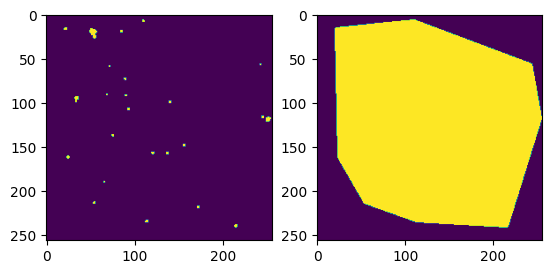

In [18]:
capsule_hull = morphology.convex_hull_image(binary_separated[200, ...])
fig, ax = plt.subplots(1, 2)
ax[0].imshow(binary_separated[200, ...])
ax[1].imshow(capsule_hull)
measure.regionprops(capsule_hull.astype(np.uint8))[0].equivalent_diameter_area